In [1]:
import json
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

In [2]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from flax.training import orbax_utils
from IPython.display import clear_output
import jax
# caching for compiled kernels
jax.config.update("jax_compilation_cache_dir", "/tmp/jax_cache")
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [3]:
from mujoco import viewer

In [4]:
from mujoco_playground import registry
from mujoco_playground import wrapper

# Locomotion

MuJoCo Playground contains a host of quadrupedal and bipedal environments (all listed below after running the command).

In [5]:
registry.locomotion.ALL_ENVS

('ApolloJoystickFlatTerrain',
 'BarkourJoystick',
 'BerkeleyHumanoidJoystickFlatTerrain',
 'BerkeleyHumanoidJoystickRoughTerrain',
 'G1JoystickFlatTerrain',
 'G1JoystickRoughTerrain',
 'Go1JoystickFlatTerrain',
 'Go1JoystickRoughTerrain',
 'Go1Getup',
 'Go1Handstand',
 'Go1Footstand',
 'H1InplaceGaitTracking',
 'H1JoystickGaitTracking',
 'Op3Joystick',
 'SpotFlatTerrainJoystick',
 'SpotGetup',
 'SpotJoystickGaitTracking',
 'T1JoystickFlatTerrain',
 'T1JoystickRoughTerrain')

# Quadrupedal

Let's jump right into quadrupedal locomotion! While we have environments available for the Google Barkour and Boston Dynamics Spot robots, the Unitree Go1 environment contains the most trainable policies that were transferred onto the real robot. We'll go right ahead and show a few policies using the Unitree Go1!

First, let's train a joystick policy, which tracks linear and yaw velocity commands.

In [6]:
env_name = 'Go1JoystickFlatTerrain'
env = registry.load(env_name)
env_cfg = registry.get_default_config(env_name)

W1206 13:18:42.758400  136025 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1206 13:18:42.760582  135843 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [ ]:
from typing import Any, Callable, Dict, List, Mapping, Optional, Sequence, Tuple, Union

Observation = Union[jax.Array, Mapping[str, jax.Array]]
ObservationSize = Union[int, Mapping[str, Union[Tuple[int, ...], int]]]

# Custom environment wrapper for modifying rewards and other step behavior
class CustomEnvWrapper:
    """Wrapper for modifying environment behavior, especially rewards."""
    
    def __init__(self, env, n_hurt_paws=1):
        self.env = env
        self.n_hurt_paws = n_hurt_paws
        # Pass through all attributes from the wrapped environment
        self.__dict__.update(env.__dict__)
        

    def reset(self, rng):
        """Reset the environment."""
        state = self.env.reset(rng)
        updated_metrics = dict(state.metrics)
        
        updated_metrics['reward/contact_penalty'] = 0.0

        chosen_leg = jax.random.randint(rng, (), 0, self.n_hurt_paws)
        chosen_leg_one_hot = jp.zeros(4).at[chosen_leg].set(1.0)
        updated_info = dict(state.info)
        updated_info['chosen_leg'] = chosen_leg_one_hot

        updated_obs = dict(state.obs)
        obs_state = updated_obs['state']
        obs_privileged_state = updated_obs['privileged_state']
        obs_state = jp.concatenate([obs_state, chosen_leg_one_hot])
        obs_privileged_state = jp.concatenate([obs_privileged_state, chosen_leg_one_hot])
        updated_obs['state'] = obs_state
        updated_obs['privileged_state'] = obs_privileged_state

        return state.replace(metrics=updated_metrics, info=updated_info, obs=updated_obs)

    def _get_obs(self, data: mjx.Data, info: dict[str, Any]) -> Dict[str, jax.Array]:
        """Get observation from simulation data and info dictionary."""
        obs = dict(self.env._get_obs(data, info))
        state = obs["state"]
        privileged_state = obs["privileged_state"]
        state = jp.concatenate([state, info['chosen_leg']])
        privileged_state = jp.concatenate([privileged_state, info['chosen_leg']])
        obs.replace(state=state, privileged_state=privileged_state)
        return obs

    @property
    def observation_size(self) -> ObservationSize:
        abstract_state = jax.eval_shape(self.reset, jax.random.PRNGKey(0))
        obs = abstract_state.obs
        if isinstance(obs, Mapping):
            return jax.tree_util.tree_map(lambda x: x.shape, obs)
        return obs.shape[-1]
    
    def step(self, state, action):
        """Step the environment and modify rewards if needed."""
        # Call the original step
        next_state = self.env.step(state, action)
        updated_obs = dict(next_state.obs)
        obs_state = updated_obs['state']
        obs_privileged_state = updated_obs['privileged_state']
        chosen_leg_one_hot = next_state.info['chosen_leg']
        obs_state = jp.concatenate([obs_state, chosen_leg_one_hot])
        obs_privileged_state = jp.concatenate([obs_privileged_state, chosen_leg_one_hot])
        updated_obs['state'] = obs_state
        updated_obs['privileged_state'] = obs_privileged_state
        
        reward = next_state.reward

        # get the information on which feet are in contact
        foot_contacts = next_state.info['last_contact']
        chosen_leg_index = jp.argmax(chosen_leg_one_hot)
        contact_penalty = foot_contacts[chosen_leg_index] * 0.1
        updated_metrics = dict(next_state.metrics)
        updated_metrics['reward/contact_penalty'] = contact_penalty

        reward -= contact_penalty

        # Replace both reward and metrics in the state
        next_state = next_state.replace(
            reward=reward,
            metrics=updated_metrics,
            obs=updated_obs
        )

        return next_state
    
    def render(self, *args, **kwargs):
        """Pass through render calls."""
        return self.env.render(*args, **kwargs)
    
    def __getattr__(self, name):
        """Delegate attribute access to the wrapped environment."""
        return getattr(self.env, name)


# Wrap the environment
env = CustomEnvWrapper(env)
# rng = jax.random.PRNGKey(0)
# env.reset(rng)
# print(env.observation_size)

In [8]:
env_cfg

Kd: 0.5
Kp: 35.0
action_repeat: 1
action_scale: 0.5
command_config:
  a:
  - 1.5
  - 0.8
  - 1.2
  b:
  - 0.9
  - 0.25
  - 0.5
ctrl_dt: 0.02
episode_length: 1000
history_len: 1
noise_config:
  level: 1.0
  scales:
    gravity: 0.05
    gyro: 0.2
    joint_pos: 0.03
    joint_vel: 1.5
    linvel: 0.1
pert_config:
  enable: false
  kick_durations:
  - 0.05
  - 0.2
  kick_wait_times:
  - 1.0
  - 3.0
  velocity_kick:
  - 0.0
  - 3.0
reward_config:
  max_foot_height: 0.1
  scales:
    action_rate: -0.01
    ang_vel_xy: -0.05
    dof_pos_limits: -1.0
    energy: -0.001
    feet_air_time: 0.1
    feet_clearance: -2.0
    feet_height: -0.2
    feet_slip: -0.1
    lin_vel_z: -0.5
    orientation: -5.0
    pose: 0.5
    stand_still: -1.0
    termination: -1.0
    torques: -0.0002
    tracking_ang_vel: 0.5
    tracking_lin_vel: 1.0
  tracking_sigma: 0.25
sim_dt: 0.004
soft_joint_pos_limit_factor: 0.95

## Joystick

Let's train the joystick policy and visualize rollouts:

In [10]:
from mujoco_playground.config import locomotion_params
ppo_params = locomotion_params.brax_ppo_config(env_name)
ppo_params["num_timesteps"] = 100_000_000
ppo_params["network_factory"]["policy_hidden_layer_sizes"] = [1024, 512, 256]
ppo_params["network_factory"]["value_hidden_layer_sizes"] = [1024, 512, 256]
ppo_params

action_repeat: 1
batch_size: 256
discounting: 0.97
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.0003
max_grad_norm: 1.0
network_factory:
  policy_hidden_layer_sizes: !!python/tuple
  - 1024
  - 512
  - 256
  policy_obs_key: state
  value_hidden_layer_sizes: !!python/tuple
  - 1024
  - 512
  - 256
  value_obs_key: privileged_state
normalize_observations: true
num_envs: 8192
num_evals: 10
num_minibatches: 32
num_resets_per_eval: 1
num_timesteps: 100000000
num_updates_per_batch: 4
reward_scaling: 1.0
unroll_length: 20

Domain randomization was used to make the policy robust to sim-to-real transfer. Certain environments in the Playground have domain randomization functions implemented. They're available in the registry and can be passed directly to brax RL algorithms. The [domain randomization](https://github.com/google-deepmind/mujoco_playground/blob/main/mujoco_playground/_src/locomotion/go1/randomize.py) function randomizes over friction, armature, center of mass of the torso, and link masses, amongst other simulation parameters.

### Train

The policy takes 7 minutes to train on an RTX 4090.

In [11]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  
  plt.errorbar(x_data, y_data, yerr=y_dataerr)

  print(f"Step: {num_steps}, Metrics: {metrics}")

  display(plt.gcf())


randomizer = registry.get_domain_randomizer(env_name)



Step: 200540160, Metrics: {'eval/walltime': 32.2713418006897, 'training/sps': np.float64(136252.0881811594), 'training/walltime': 1535.562783241272, 'training/entropy_loss': Array(0.1, dtype=float32), 'training/policy_loss': Array(-0.017, dtype=float32), 'training/total_loss': Array(0.083, dtype=float32), 'training/v_loss': Array(0., dtype=float32), 'eval/episode_reward': Array(24.951, dtype=float32), 'eval/episode_reward/action_rate': Array(-10.443, dtype=float32), 'eval/episode_reward/ang_vel_xy': Array(-39.671, dtype=float32), 'eval/episode_reward/contact_penalty': Array(0.116, dtype=float32), 'eval/episode_reward/dof_pos_limits': Array(-0., dtype=float32), 'eval/episode_reward/energy': Array(-141.315, dtype=float32), 'eval/episode_reward/feet_air_time': Array(1.017, dtype=float32), 'eval/episode_reward/feet_clearance': Array(-220.176, dtype=float32), 'eval/episode_reward/feet_height': Array(-4.888, dtype=float32), 'eval/episode_reward/feet_slip': Array(-17.395, dtype=float32), 'eva

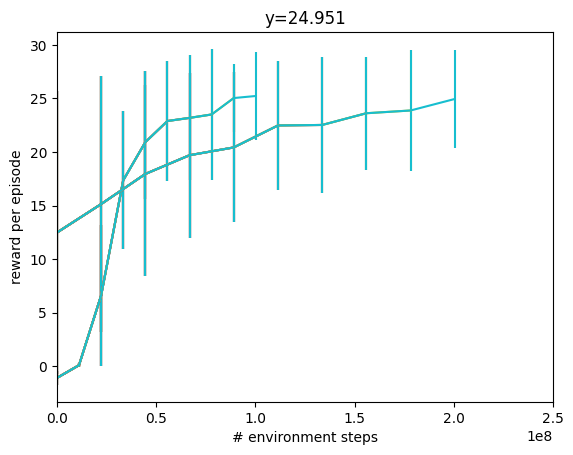

Saved to: /home/erdem/Code/RL/hurt_paw/checkpoints/params_2
Curriculum Complete
time to jit: 0:00:17.193079
time to train: 0:39:03.770563


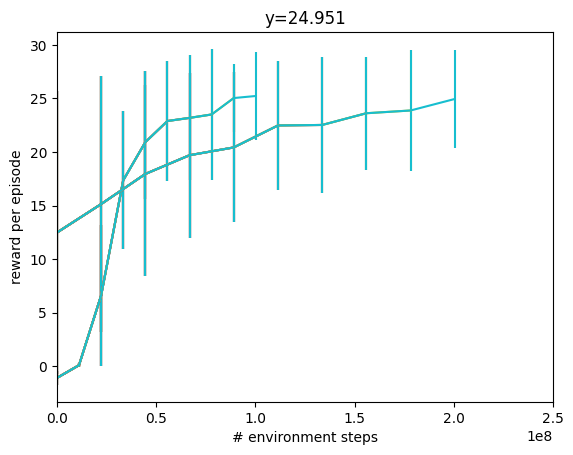

In [12]:
import os
checkpointer = ocp.PyTreeCheckpointer()

cwd = os.getcwd()
checkpoint_relative = "checkpoints"
checkpoint_abs = os.path.join(cwd, checkpoint_relative)
print(f"Checkpoint directory: {checkpoint_abs}")
os.makedirs(checkpoint_abs, exist_ok=True)


for i in range(1, 3):
    ppo_params["num_timesteps"] = 100_000_000 * i

    print(f"\n--- Starting Curriculum Phase {i} ---")

    # Create environment for this phase
    env = CustomEnvWrapper(
        registry.load(env_name, config=env_cfg),
        n_hurt_paws=i
    )

    eval_env = CustomEnvWrapper(
        registry.load(env_name, config=env_cfg),
        n_hurt_paws=i
    )
    
    # Configure restoration path
    extra_params = {}
    if i > 1:
        # Points to the DIRECTORY created by Orbax in the previous step
        prev_path = os.path.join(checkpoint_abs, f"params_{i-1}")
        extra_params["restore_checkpoint_path"] = prev_path
        print(f"Restoring from: {prev_path}")

    ppo_training_params = dict(ppo_params)
    network_factory = ppo_networks.make_ppo_networks
    if "network_factory" in ppo_params:
        del ppo_training_params["network_factory"]

        network_factory = functools.partial(
            ppo_networks.make_ppo_networks,
            **ppo_params.network_factory
        )

    train_fn = functools.partial(
        ppo.train, **dict(ppo_training_params),
        network_factory=network_factory,
        randomization_fn=randomizer,
        progress_fn=progress
    )


    # Train
    make_inference_fn, params, metrics = train_fn(
        environment=env,
        **extra_params,
        eval_env=eval_env,
        wrap_env_fn=wrapper.wrap_for_brax_training,
    )


    x_data, y_data, y_dataerr = [], [], []

    # 2. Save using Orbax
    # This creates a folder 'params_{i}' containing the checkpoint data
    save_path = os.path.join(checkpoint_abs, f"params_{i}")
    save_args = orbax_utils.save_args_from_target(params)
    checkpointer.save(save_path, params, save_args=save_args, force=True)
    print(f"Saved to: {save_path}")

print("Curriculum Complete")
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [14]:
params

(RunningStatisticsState(mean={'privileged_state': Array([-0.033,  0.008,  0.021, -0.067, -0.023,  0.004, -0.009,  0.018, -0.981,  0.023, -0.006,
        -0.225, -0.101,  0.03 , -0.113, -0.012,  0.023, -0.038,  0.028,  0.022, -0.126,  0.029,
         0.009, -0.028, -0.05 ,  0.045, -0.075,  0.02 ,  0.   , -0.055, -0.021,  0.007, -0.099,
         0.011, -0.011, -0.291, -0.17 , -0.01 ,  0.118,  0.024,  0.07 ,  0.242,  0.044,  0.086,
        -0.024, -0.002, -0.   ,  0.   , -0.067, -0.023,  0.004, -0.005,  0.094,  9.825, -0.009,
         0.018, -0.981, -0.033,  0.008,  0.021, -0.001, -0.002, -0.   ,  0.023, -0.006, -0.225,
        -0.101,  0.03 , -0.113, -0.012,  0.023, -0.038,  0.028,  0.022, -0.126,  0.029,  0.008,
        -0.028, -0.05 ,  0.046, -0.075,  0.02 ,  0.   , -0.055, -0.021,  0.007, -0.099, -0.602,
         0.018,  2.771,  0.56 , -1.218,  6.017,  0.827,  0.411,  5.538, -0.202,  0.724,  3.984,
         0.275,  0.512,  0.64 ,  0.473, -0.   ,  0.   ,  0.051, -0.   , -0.   ,  0.053,

Let's rollout and render the resulting policy!

In [15]:
# Enable perturbation in the eval env.
env_cfg = registry.get_default_config(env_name)
env_cfg.pert_config.enable = True
env_cfg.pert_config.velocity_kick = [3.0, 6.0]
env_cfg.pert_config.kick_wait_times = [5.0, 15.0]
env_cfg.command_config.a = [1.5, 0.8, 2*jp.pi]
eval_env = registry.load(env_name, config=env_cfg)
eval_env = CustomEnvWrapper(eval_env)
velocity_kick_range = [0.0, 0.0]  # Disable velocity kick.
kick_duration_range = [0.05, 0.2]

jit_reset = jax.jit(eval_env.reset)
jit_step = jax.jit(eval_env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
#@title Rollout and Render
from mujoco_playground._src.gait import draw_joystick_command

x_vel = 0.0  #@param {type: "number"}
y_vel = 0.0  #@param {type: "number"}
yaw_vel = 3.14  #@param {type: "number"}


def sample_pert(rng):
  rng, key1, key2 = jax.random.split(rng, 3)
  pert_mag = jax.random.uniform(
      key1, minval=velocity_kick_range[0], maxval=velocity_kick_range[1]
  )
  duration_seconds = jax.random.uniform(
      key2, minval=kick_duration_range[0], maxval=kick_duration_range[1]
  )
  duration_steps = jp.round(duration_seconds / eval_env.dt).astype(jp.int32)
  state.info["pert_mag"] = pert_mag
  state.info["pert_duration"] = duration_steps
  state.info["pert_duration_seconds"] = duration_seconds
  return rng


rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []

swing_peak = []
rewards = []
linvel = []
angvel = []
track = []
foot_vel = []
rews = []
contact = []
command = jp.array([x_vel, y_vel, yaw_vel])

state = jit_reset(rng)
if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
  rng = sample_pert(rng)
state.info["command"] = command
state.info["chosen_leg"] = jp.array([1.0, 0.0, 0.0, 0.0])
for i in range(env_cfg.episode_length):
  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  state.info["command"] = command
  state.info["chosen_leg"] = jp.array([1.0, 0.0, 0.0, 0.0])
  rews.append(
      {k: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  rewards.append(
      {k[7:]: v for k, v in state.metrics.items() if k.startswith("reward/")}
  )
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  track.append(
      env._reward_tracking_lin_vel(
          state.info["command"], env.get_local_linvel(state.data)
      )
  )

  feet_vel = state.data.sensordata[env._foot_linvel_sensor_adr]
  vel_xy = feet_vel[..., :2]
  vel_norm = jp.sqrt(jp.linalg.norm(vel_xy, axis=-1))
  foot_vel.append(vel_norm)

  contact.append(state.info["last_contact"])

  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=state.info["command"],
          xyz=xyz,
          theta=yaw,
          scl=abs(state.info["command"][0])
          / env_cfg.command_config.a[0],
      )
  )


render_every = 2
fps = 1.0 / eval_env.dt / render_every
traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    scene_option=scene_option,
    width=640,
    height=480,
    modify_scene_fns=mod_fns,
)
media.show_video(frames, fps=fps, loop=False)

Let's visualize the feet positions and the positional drift compared to the commanded linear and angular velocity. This is useful for debugging how well the policy follows the commands!

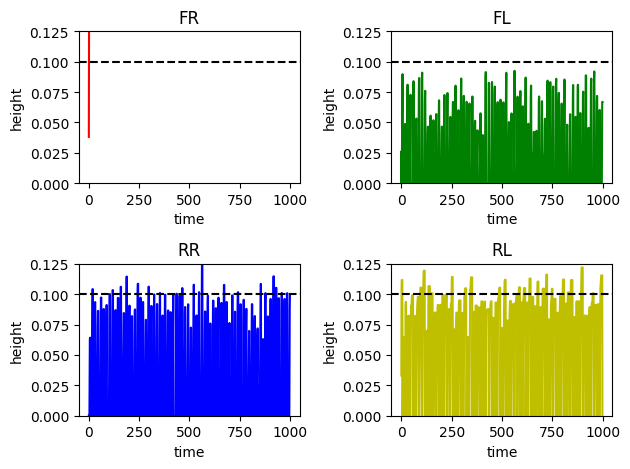

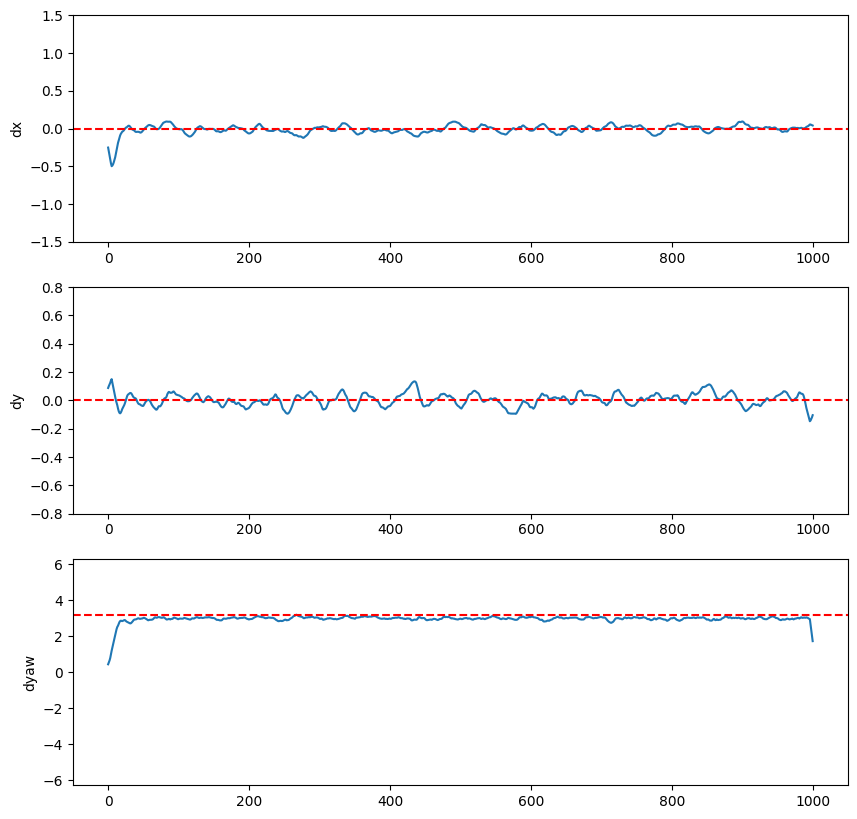

In [17]:
#@title Plot each foot in a 2x2 grid.

swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])

Now let's visualize what it looks like to slowly increase linear velocity commands.

In [ ]:
#@title Slowly increase linvel commands

rng = jax.random.PRNGKey(0)
rollout = []
modify_scene_fns = []
swing_peak = []
linvel = []
angvel = []

x = -0.25
command = jp.array([x, 0, 0])
state = jit_reset(rng)
for i in range(1_400):
  # Increase the forward velocity by 0.25 m/s every 200 steps.
  if i % 200 == 0:
    x += 0.25
    print(f"Setting x to {x}")
    command = jp.array([x, 0, 0])
  state.info["command"] = command
  state.info["chosen_leg"] = jp.array([1.0, 0.0, 0.0, 0.0])

  if state.info["steps_since_last_pert"] < state.info["steps_until_next_pert"]:
    rng = sample_pert(rng)
  act_rng, rng = jax.random.split(rng)
  ctrl, _ = jit_inference_fn(state.obs, act_rng)
  state = jit_step(state, ctrl)
  rollout.append(state)
  swing_peak.append(state.info["swing_peak"])
  linvel.append(env.get_global_linvel(state.data))
  angvel.append(env.get_gyro(state.data))
  xyz = np.array(state.data.xpos[env._torso_body_id])
  xyz += np.array([0, 0, 0.2])
  x_axis = state.data.xmat[env._torso_body_id, 0]
  yaw = -np.arctan2(x_axis[1], x_axis[0])
  modify_scene_fns.append(
      functools.partial(
          draw_joystick_command,
          cmd=command,
          xyz=xyz,
          theta=yaw,
          scl=abs(command[0]) / env_cfg.command_config.a[0],
      )
  )


# Plot each foot in a 2x2 grid.
swing_peak = jp.array(swing_peak)
names = ["FR", "FL", "RR", "RL"]
colors = ["r", "g", "b", "y"]
fig, axs = plt.subplots(2, 2)
for i, ax in enumerate(axs.flat):
  ax.plot(swing_peak[:, i], color=colors[i])
  ax.set_ylim([0, env_cfg.reward_config.max_foot_height * 1.25])
  ax.axhline(env_cfg.reward_config.max_foot_height, color="k", linestyle="--")
  ax.set_title(names[i])
  ax.set_xlabel("time")
  ax.set_ylabel("height")
plt.tight_layout()
plt.show()

linvel_x = jp.array(linvel)[:, 0]
linvel_y = jp.array(linvel)[:, 1]
angvel_yaw = jp.array(angvel)[:, 2]

# Plot whether velocity is within the command range.
linvel_x = jp.convolve(linvel_x, jp.ones(10) / 10, mode="same")
linvel_y = jp.convolve(linvel_y, jp.ones(10) / 10, mode="same")
angvel_yaw = jp.convolve(angvel_yaw, jp.ones(10) / 10, mode="same")

fig, axes = plt.subplots(3, 1, figsize=(10, 10))
axes[0].plot(linvel_x)
axes[1].plot(linvel_y)
axes[2].plot(angvel_yaw)

axes[0].set_ylim(
    -env_cfg.command_config.a[0], env_cfg.command_config.a[0]
)
axes[1].set_ylim(
    -env_cfg.command_config.a[1], env_cfg.command_config.a[1]
)
axes[2].set_ylim(
    -env_cfg.command_config.a[2], env_cfg.command_config.a[2]
)

for i, ax in enumerate(axes):
  ax.axhline(state.info["command"][i], color="red", linestyle="--")

labels = ["dx", "dy", "dyaw"]
for i, ax in enumerate(axes):
  ax.set_ylabel(labels[i])


render_every = 2
fps = 1.0 / eval_env.dt / render_every
print(f"fps: {fps}")

traj = rollout[::render_every]
mod_fns = modify_scene_fns[::render_every]
assert len(traj) == len(mod_fns)

scene_option = mujoco.MjvOption()
scene_option.geomgroup[2] = True
scene_option.geomgroup[3] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE] = True

frames = eval_env.render(
    traj,
    camera="track",
    height=480,
    width=640,
    modify_scene_fns=mod_fns,
    scene_option=scene_option,
)
media.show_video(frames, fps=fps, loop=False)

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import PIL.Image
import io
import time
import threading
import traceback
import mujoco
from mujoco import mjx
import numpy as np
from jax import numpy as jp
import jax

RENDER_WIDTH = 480
RENDER_HEIGHT = 360
STEPS_PER_RENDER = 5 

vx_slider = widgets.FloatSlider(value=0.0, min=-1.5, max=1.5, step=0.1, description='Fwd/Back')
vy_slider = widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1, description='Strafe')
wz_slider = widgets.FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='Turn')

leg_dropdown = widgets.Dropdown(
    options=[('Leg 0 (FR)', 0), ('Leg 1 (FL)', 1)],
    value=0,
    description='Select Leg:',
    style={'description_width': 'initial'}
)

reset_button = widgets.Button(description="Reset Robot")
stop_button = widgets.ToggleButton(value=False, description='Stop Simulation', button_style='danger')

image_widget = widgets.Image(format='jpeg', width=RENDER_WIDTH, height=RENDER_HEIGHT)
status_label = widgets.Label(value="Status: Ready")

ui = widgets.VBox([
    widgets.HBox([vx_slider, vy_slider, wz_slider]),
    widgets.HBox([leg_dropdown, reset_button, stop_button, status_label]),
    image_widget
])

display(ui)

class InteractiveCustomEnvWrapper:
    def __init__(self, env):
        self.env = env
        self.__dict__.update(env.__dict__)

    def reset(self, rng):
        state = self.env.reset(rng)
        # Default to leg 0 on reset
        chosen_leg_one_hot = jp.array([1.0, 0.0, 0.0, 0.0])
        updated_info = state.info.copy()
        updated_info['chosen_leg'] = chosen_leg_one_hot
        
        updated_obs = state.obs.copy()
        updated_obs['state'] = jp.concatenate([updated_obs['state'], chosen_leg_one_hot])
        updated_obs['privileged_state'] = jp.concatenate([updated_obs['privileged_state'], chosen_leg_one_hot])
        return state.replace(info=updated_info, obs=updated_obs)

    def step(self, state, action):
        next_state = self.env.step(state, action)
        chosen_leg_one_hot = state.info['chosen_leg'] 
        updated_obs = next_state.obs.copy()
        updated_obs['state'] = jp.concatenate([updated_obs['state'], chosen_leg_one_hot])
        updated_obs['privileged_state'] = jp.concatenate([updated_obs['privileged_state'], chosen_leg_one_hot])
        updated_info = next_state.info.copy()
        updated_info['chosen_leg'] = chosen_leg_one_hot
        return next_state.replace(obs=updated_obs, info=updated_info)

    def __getattr__(self, name):
        return getattr(self.env, name)

# --- Global State Holder for Reset ---
global_state_container = {'reset_needed': False}

def on_reset_click(b):
    global_state_container['reset_needed'] = True

reset_button.on_click(on_reset_click)

def run_interactive_sim():
    try:
        env_cfg = registry.get_default_config(env_name)
        base_env = registry.load(env_name, config=env_cfg)
        eval_env = InteractiveCustomEnvWrapper(base_env)
        
        rng = jax.random.PRNGKey(int(time.time()))
        jit_reset = jax.jit(eval_env.reset)
        jit_step = jax.jit(eval_env.step)
        jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))
        
        # Initial Reset
        state = jit_reset(rng)
        
        # Renderer setup
        mj_data = mujoco.MjData(eval_env.mj_model)
        renderer = mujoco.Renderer(eval_env.mj_model, height=RENDER_HEIGHT, width=RENDER_WIDTH)
        
        # Scene Options
        scene_option = mujoco.MjvOption()
        scene_option.geomgroup[2] = True # Visuals
        scene_option.geomgroup[3] = False # Collision geoms
        
        status_label.value = "Status: Running"
        
        while not stop_button.value:
            # Control frame rate
            time.sleep(0.01)
            
            if global_state_container['reset_needed'] or np.isnan(state.data.qpos).any():
                rng = jax.random.split(rng)[0]
                state = jit_reset(rng)
                global_state_container['reset_needed'] = False
                status_label.value = "Status: Resetting..."
                continue
            else:
                status_label.value = "Status: Running"

            cmd_x = float(vx_slider.value)
            cmd_y = float(vy_slider.value)
            cmd_yaw = float(wz_slider.value)
            current_command = jp.array([cmd_x, cmd_y, cmd_yaw], dtype=jp.float32)
            
            leg_idx = leg_dropdown.value
            current_leg_mask = jp.array([1.0 if i == leg_idx else 0.0 for i in range(4)], dtype=jp.float32)
            
            for _ in range(STEPS_PER_RENDER):
                # Inject State
                new_info = state.info.copy()
                new_info['command'] = current_command
                new_info['chosen_leg'] = current_leg_mask
                state = state.replace(info=new_info)
                
                # Inference & Step
                act_rng, rng = jax.random.split(rng)
                ctrl, _ = jit_inference_fn(state.obs, act_rng)
                state = jit_step(state, ctrl)

            mj_data = mjx.get_data(eval_env.mj_model, state.data)
            mujoco.mj_forward(eval_env.mj_model, mj_data)
            
            renderer.update_scene(mj_data, camera="track", scene_option=scene_option)
            pixels = renderer.render()
            
            img = PIL.Image.fromarray(np.array(pixels, dtype=np.uint8))
            with io.BytesIO() as bio:
                img.save(bio, format='jpeg')
                image_widget.value = bio.getvalue()

        status_label.value = "Status: Stopped"
        
    except Exception as e:
        status_label.value = f"Error: {str(e)}"
        traceback.print_exc()

# slider values don't get updated without a thread loop
for thread in threading.enumerate():
    if thread.name == "SimThread":
        stop_button.value = True
        thread.join(timeout=1.0)
        stop_button.value = False

sim_thread = threading.Thread(target=run_interactive_sim, name="SimThread")
sim_thread.start()